# Hospital Bed-Day Prediction using Regularized Regression Models



In [20]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [21]:
# Load the dataset
df = pd.read_csv("datasets/DEEP-Q1-hospital_bed_days_regression_data.csv")

TARGET           = 'bed_days_30d'
RANDOM_STATE     = 42
TEST_SIZE        = 0.20
CV_FOLDS         = 5
# Define feature columns
NUMERICAL_COLS   = ['age', 'cci', 'los_index', 'prior_adm_12m',
                    'crp', 'creatinine', 'has_carer', 'imd']
CATEGORICAL_COLS = ['site']

print(f"Dimensions of the dataset:", df.shape)
print(f"Missing values : {df.isnull().sum().sum()}")
print(f"Target summary:")
print( df[TARGET].describe().to_string())
print(f"Target column  : '{TARGET}'")
df.head()


Dimensions of the dataset: (2400, 10)
Missing values : 0
Target summary:
count    2400.000000
mean        8.447917
std         2.609302
min         1.000000
25%         7.000000
50%         8.000000
75%        10.000000
max        18.000000
Target column  : 'bed_days_30d'


,age,cci,los_index,prior_adm_12m,crp,creatinine,has_carer,imd,site,bed_days_30d
0,73,2,5,2,36.2,163.1,1,4,0,10
1,65,2,2,1,43.6,103.7,1,9,1,5
2,75,4,6,0,52.6,57.9,0,7,0,11
3,85,5,3,2,30.3,88.7,1,6,0,10
4,64,4,3,0,56.3,87.9,0,2,0,9


In [22]:
# split the dataset into train and test sets
X = df.drop(columns=[TARGET])
y = df[TARGET] 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print(" Train and test split 80/20 \n " + f"Train: {len(X_train)} samples \n Test: {len(X_test)} samples")


 Train and test split 80/20 
 Train: 1920 samples 
 Test: 480 samples


In [23]:
#  preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', StandardScaler(),NUMERICAL_COLS),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), CATEGORICAL_COLS),
], remainder='drop')

### (a). Fit and evaluate multiple regression models 
Four regression models—OLS, Ridge, Lasso, and ElasticNet—were developed using scikit-learn pipelines with feature scaling and categorical encoding. Hyperparameters for Ridge, Lasso, and ElasticNet were optimised using five-fold cross-validation and GridSearchCV. Models were evaluated on an 80/20 train-test split using MAE, RMSE, and R². MAE was selected as the primary metric due to its direct relevance to hospital bed-day prediction accuracy.

In [24]:
# Define models and hyperparameters for tuning
model_configs = {
    'OLS': (
        LinearRegression(),
        {}                                  
    ),
    'Ridge': (
        Ridge(max_iter=10000),
        {'regressor__alpha': np.logspace(-3, 3, 20)}
    ),
    'Lasso': (
        Lasso(max_iter=10000),
        {'regressor__alpha': np.logspace(-4, 1, 20)}
    ),
    'ElasticNet': (
        ElasticNet(max_iter=10000),
        {
            'regressor__alpha':     np.logspace(-4, 1, 10),
            'regressor__l1_ratio':  [0.2, 0.5, 0.8]
        }
    ),
}
#
 

### (b) Automated Model Selection

Automated model selection was performed using GridSearchCV with five-fold cross-validation, selecting the model with the lowest CV MAE. Lasso Regression achieved the best performance, with a CV MAE of 1.20 days and a test MAE of 1.22 days. The model explained 67.6% of the variance in bed-days (R² = 0.676) with an RMSE of 1.5 days. The close agreement between cross-validation and test results indicates good generalisation and minimal overfitting.


In [25]:
# Train and evaluate each model using cross-validation and test set performance
print(f" Training models with {CV_FOLDS}-fold cross-validation")
print("─" * 50)
results       = []
fitted_models = {}

best_overall_cv_mae = float('inf')   
final_model         = None
final_model_name    = None

for name, (estimator, param_grid) in model_configs.items():

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor',    estimator),
    ])

    # GridSearchCV
    search = GridSearchCV(
        pipeline,
        param_grid,
        cv=CV_FOLDS,
        scoring='neg_mean_absolute_error',
        n_jobs=-1,
        refit=True,
    )
    search.fit(X_train, y_train)
    best_pipe = search.best_estimator_

    # Evaluate on held-out test set
    y_pred = best_pipe.predict(X_test)
    mae    = mean_absolute_error(y_test, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    r2     = r2_score(y_test, y_pred)

    # Cross-validated MAE on training data
    cv_mae = -cross_val_score(
        best_pipe, X_train, y_train,
        cv=CV_FOLDS, scoring='neg_mean_absolute_error'
    ).mean()

    best_params = {k.replace('regressor__', ''): round(v, 6)
                   for k, v in search.best_params_.items()} if search.best_params_ else 'N/A'

    results.append({
        'Model':       name,
        'CV MAE':      round(cv_mae,  4),
        'MAE (Test)':  round(mae,     4),
        'RMSE (Test)': round(rmse,    4),
        'R² (Test)':   round(r2,      4),
        'Best Params': best_params,
    })

    fitted_models[name] = best_pipe
    print(f"  {name:<12} | CV MAE={cv_mae:.4f} | Test MAE={mae:.4f} | RMSE={rmse:.4f} | R²={r2:.4f}")

    # <-- change: select by CV MAE, not test MAE
    if cv_mae < best_overall_cv_mae:
        best_overall_cv_mae = cv_mae
        final_model         = best_pipe
        final_model_name    = name

 Training models with 5-fold cross-validation
──────────────────────────────────────────────────
  OLS          | CV MAE=1.2025 | Test MAE=1.2160 | RMSE=1.4962 | R²=0.6776
  Ridge        | CV MAE=1.2024 | Test MAE=1.2168 | RMSE=1.4967 | R²=0.6774
  Lasso        | CV MAE=1.2019 | Test MAE=1.2185 | RMSE=1.4995 | R²=0.6762
  ElasticNet   | CV MAE=1.2020 | Test MAE=1.2177 | RMSE=1.4981 | R²=0.6768


In [26]:
# Display results in 
results_df = pd.DataFrame(results)
print("─" * 50)
print("AUTOMATED MODEL SELECTION RESULTS")
print("─" * 50)
print(results_df[['Model', 'CV MAE', 'MAE (Test)',
                   'RMSE (Test)', 'R² (Test)']].to_string(index=False))
print("─" * 50)
print(f"Selected model: {final_model_name}  "
      f"(lowest CV MAE = {best_overall_cv_mae:.4f})")
print("─" * 50)
 

r2_range = results_df['R² (Test)'].max() - results_df['R² (Test)'].min()

──────────────────────────────────────────────────
AUTOMATED MODEL SELECTION RESULTS
──────────────────────────────────────────────────
     Model  CV MAE  MAE (Test)  RMSE (Test)  R² (Test)
       OLS  1.2025      1.2160       1.4962     0.6776
     Ridge  1.2024      1.2168       1.4967     0.6774
     Lasso  1.2019      1.2185       1.4995     0.6762
ElasticNet  1.2020      1.2177       1.4981     0.6768
──────────────────────────────────────────────────
Selected model: Lasso  (lowest CV MAE = 1.2019)
──────────────────────────────────────────────────


In [27]:
print("FITTED PARAMETERS : Lasso — standardised coefficients")
print("─" * 50)

cat_encoder   = final_model.named_steps['preprocessor'] \
                            .named_transformers_['cat']
cat_features  = list(cat_encoder.get_feature_names_out(CATEGORICAL_COLS))
all_features  = NUMERICAL_COLS + cat_features

lasso_reg     = final_model.named_steps['regressor']
coefficients  = lasso_reg.coef_
intercept     = lasso_reg.intercept_

coeff_df = pd.DataFrame({
    'Feature':     all_features,
    'Coefficient': coefficients,
}).sort_values('Coefficient', ascending=False).reset_index(drop=True)

# results
print(f"Intercept: {intercept:.4f}  - baseline predicted bed days")
print("─" * 50)
print(coeff_df.to_string(index=False))

FITTED PARAMETERS : Lasso — standardised coefficients
──────────────────────────────────────────────────
Intercept: 8.4448  - baseline predicted bed days
──────────────────────────────────────────────────
      Feature  Coefficient
          cci     1.536186
prior_adm_12m     0.853632
    los_index     0.740194
          age     0.438000
          crp     0.399704
   creatinine     0.311512
       site_1     0.000000
    has_carer    -0.205192
          imd    -0.206649


In [28]:
full_mae = mean_absolute_error(y_test, final_model.predict(X_test))

def subset_lasso(num_cols, label):
    pipe = Pipeline([
        ("preprocessor", ColumnTransformer([
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(drop="first", sparse_output=False), CATEGORICAL_COLS),
        ])),
        ("regressor", Lasso()),
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    return pipe, {
        "Model": label,
        "MAE": round(mean_absolute_error(y_test, pred), 4),
        "R²": round(r2_score(y_test, pred), 4),
        "MAE increase vs full Lasso": round(mean_absolute_error(y_test, pred) - full_mae, 4),
    }

admission_model, row_adm = subset_lasso(
    ["age", "cci", "los_index", "prior_adm_12m", "has_carer", "imd"],
    "Admission-time Lasso"
)

robust_model, row_rob = subset_lasso(
    ["age", "cci", "los_index", "prior_adm_12m", "crp", "creatinine"],
    "Robust Lasso"
)

pd.DataFrame([row_adm, row_rob])


,Model,MAE,R²,MAE increase vs full Lasso
0,Admission-time Lasso,1.8492,0.2186,0.6306
1,Robust Lasso,1.8492,0.2186,0.6306


In [29]:
high_crp = X_test["crp"] >= X_test["crp"].quantile(0.80)
X_high = X_test.loc[high_crp].copy()
y_high = y_test.loc[high_crp]

pred_normal = final_model.predict(X_high)
pred_zero = final_model.predict(X_high.assign(crp=0.0))
pred_mean = final_model.predict(X_high.assign(crp=X_train["crp"].mean()))

failure_df = pd.DataFrame({
    "Scenario": [
        "Normal CRP available",
        "CRP missing - set to 0",
        "CRP missing - mean imputation",
    ],
    "MAE": [
        round(mean_absolute_error(y_high, pred_normal), 4),
        round(mean_absolute_error(y_high, pred_zero), 4),
        round(mean_absolute_error(y_high, pred_mean), 4),
    ],
})

mean_gap = (pred_normal - pred_zero).mean()
n_patients = 85 


print(
    f"High-CRP patients: {high_crp.sum()} "
    f"(CRP >= {X_test['crp'].quantile(0.80):.1f})"
)

print(
    f"missing CRP is set to 0: "
    f"{mean_gap:.2f} bed-days per patient"
)

print(
    f"eg {n_patients} patients are affected, demand :  "
    f" {n_patients * mean_gap:.0f} bed-days."
)

High-CRP patients: 96 (CRP >= 69.8)
missing CRP is set to 0: 1.28 bed-days per patient
eg 85 patients are affected, demand :   109 bed-days.


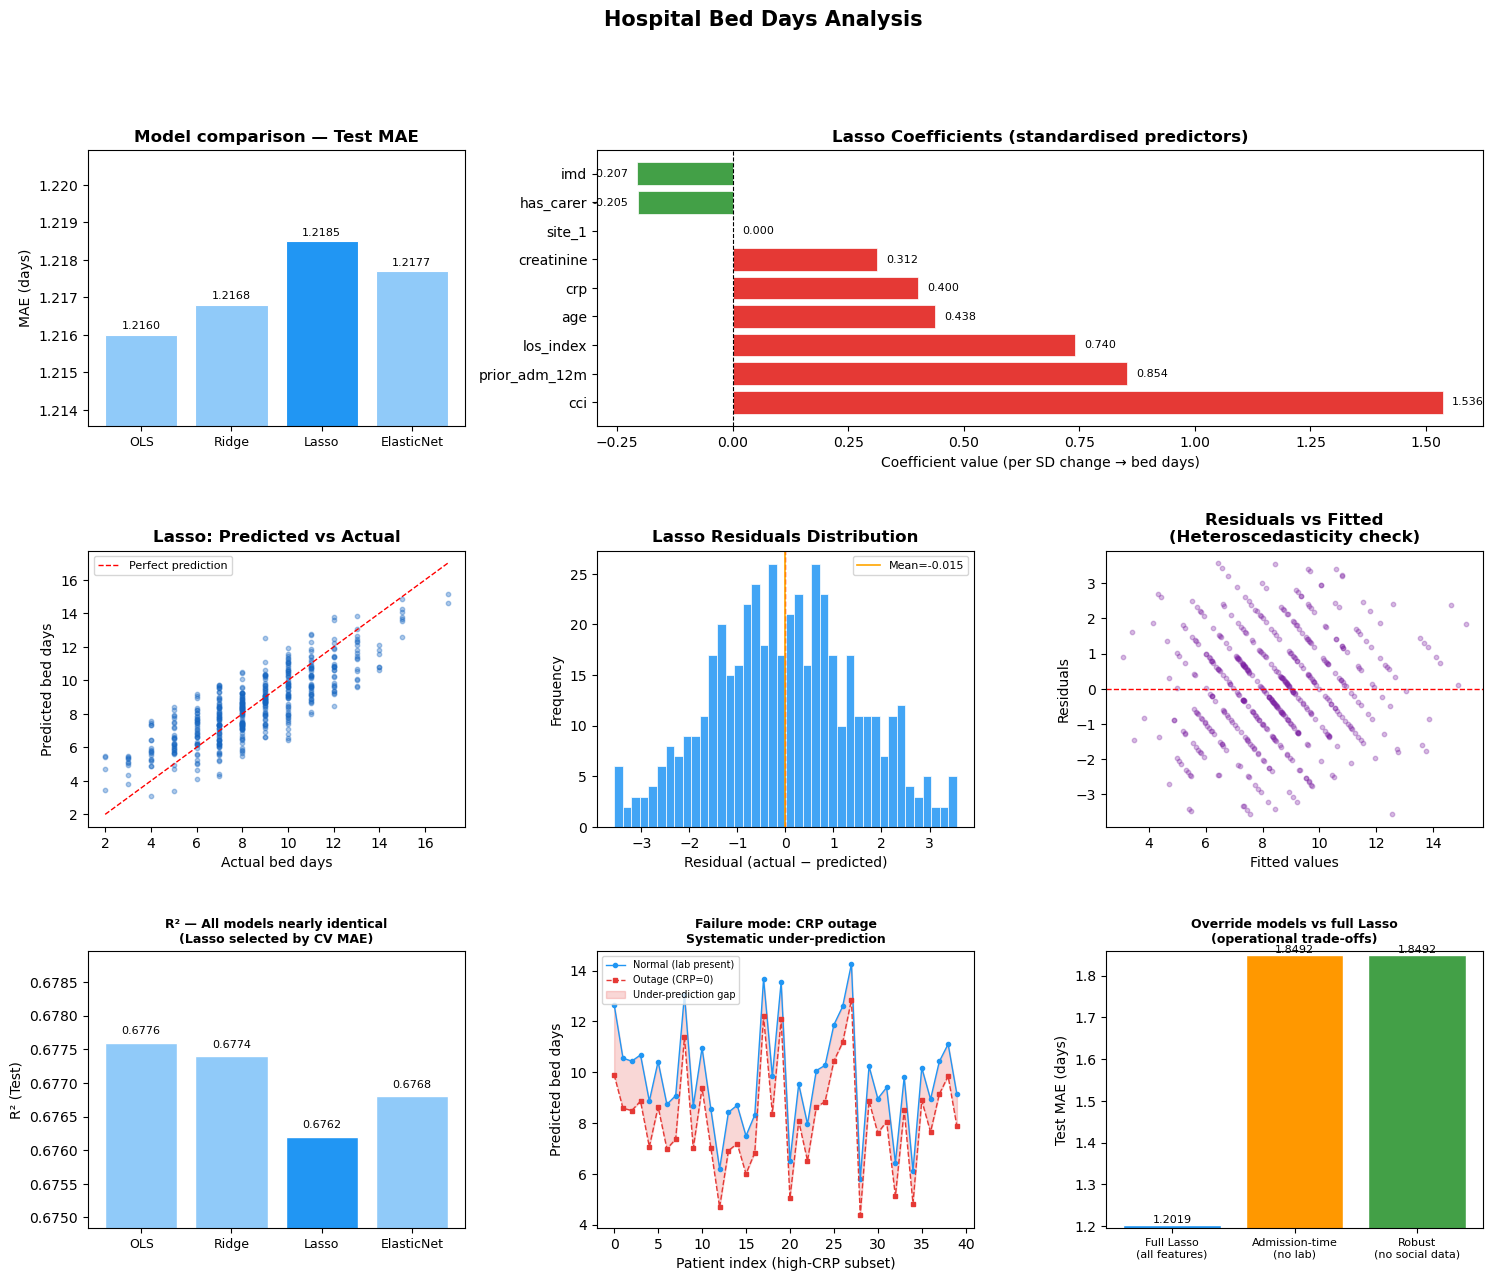

In [30]:
# visualisations
fig = plt.figure(figsize=(18, 14))
fig.suptitle("Hospital Bed Days Analysis", fontsize=15, fontweight='bold', y=0.98)
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
model_names = results_df['Model']
test_maes   = results_df['MAE (Test)']
colours     = ['#2196F3' if n == final_model_name else '#90CAF9' for n in model_names]
bars = ax1.bar(model_names, test_maes, color=colours, edgecolor='white', linewidth=0.8)
ax1.set_title('Model comparison — Test MAE', fontweight='bold')
ax1.set_ylabel('MAE (days)')
ax1.set_ylim(test_maes.min() * 0.998, test_maes.max() * 1.002)
for bar, val in zip(bars, test_maes):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
             f'{val:.4f}', ha='center', va='bottom', fontsize=8)
ax1.tick_params(axis='x', labelsize=9)

ax2 = fig.add_subplot(gs[0, 1:])
coeff_plot = coeff_df.copy()
colours_coef = ['#E53935' if c > 0 else '#43A047'
                for c in coeff_plot['Coefficient']]
bars2 = ax2.barh(coeff_plot['Feature'], coeff_plot['Coefficient'],
                 color=colours_coef, edgecolor='white', linewidth=0.5)
ax2.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_title('Lasso Coefficients (standardised predictors)', fontweight='bold')  # CHANGED
ax2.set_xlabel('Coefficient value (per SD change → bed days)')
for bar, val in zip(bars2, coeff_plot['Coefficient']):
    xpos = val + 0.02 if val >= 0 else val - 0.02
    ha   = 'left'      if val >= 0 else 'right'
    ax2.text(xpos, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', ha=ha, fontsize=8)

ax3 = fig.add_subplot(gs[1, 0])
y_pred_full = final_model.predict(X_test)
ax3.scatter(y_test, y_pred_full, alpha=0.35, s=10, color='#1565C0')
lims = [min(y_test.min(), y_pred_full.min()), max(y_test.max(), y_pred_full.max())]
ax3.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
ax3.set_xlabel('Actual bed days')
ax3.set_ylabel('Predicted bed days')
ax3.set_title('Lasso: Predicted vs Actual', fontweight='bold')  # CHANGED
ax3.legend(fontsize=8)

ax4 = fig.add_subplot(gs[1, 1])
residuals = y_test - y_pred_full
ax4.hist(residuals, bins=40, color='#42A5F5', edgecolor='white', linewidth=0.5)
ax4.axvline(0, color='red', linestyle='--', linewidth=1)
ax4.axvline(residuals.mean(), color='orange', linestyle='-',
            linewidth=1.2, label=f'Mean={residuals.mean():.3f}')
ax4.set_xlabel('Residual (actual − predicted)')
ax4.set_ylabel('Frequency')
ax4.set_title('Lasso Residuals Distribution', fontweight='bold')  # CHANGED
ax4.legend(fontsize=8)

ax5 = fig.add_subplot(gs[1, 2])
ax5.scatter(y_pred_full, residuals, alpha=0.3, s=10, color='#7B1FA2')
ax5.axhline(0, color='red', linestyle='--', linewidth=1)
ax5.set_xlabel('Fitted values')
ax5.set_ylabel('Residuals')
ax5.set_title('Residuals vs Fitted\n(Heteroscedasticity check)', fontweight='bold')

ax6 = fig.add_subplot(gs[2, 0])
r2_vals   = results_df['R² (Test)']
cols_r2   = ['#2196F3' if n == final_model_name else '#90CAF9' for n in model_names]
ax6.bar(model_names, r2_vals, color=cols_r2, edgecolor='white')
ax6.set_title('R² — All models nearly identical\n(Lasso selected by CV MAE)',
              fontweight='bold', fontsize=9)  # CHANGED
ax6.set_ylabel('R² (Test)')
ax6.set_ylim(r2_vals.min() * 0.998, r2_vals.max() * 1.002)
for i, (name, val) in enumerate(zip(model_names, r2_vals)):
    ax6.text(i, val + 0.0001, f'{val:.4f}', ha='center', va='bottom', fontsize=8)
ax6.tick_params(axis='x', labelsize=9)

ax7 = fig.add_subplot(gs[2, 1])
high_crp_idx = X_test['crp'].nlargest(40).index
X_high_crp = X_test.loc[high_crp_idx].copy()

y_pred_normal = final_model.predict(X_high_crp)

X_outage = X_high_crp.copy()
X_outage['crp'] = 0
y_pred_outage = final_model.predict(X_outage)

n_show = min(40, len(y_pred_normal))
x_idx    = np.arange(n_show)
ax7.plot(x_idx, y_pred_normal[:n_show], 'o-',  color='#2196F3',
         markersize=3, linewidth=1, label='Normal (lab present)')
ax7.plot(x_idx, y_pred_outage[:n_show], 's--', color='#E53935',
         markersize=3, linewidth=1, label='Outage (CRP=0)')
ax7.fill_between(x_idx,
                 y_pred_outage[:n_show],
                 y_pred_normal[:n_show],
                 alpha=0.2, color='#E53935', label='Under-prediction gap')
ax7.set_xlabel('Patient index (high-CRP subset)')
ax7.set_ylabel('Predicted bed days')
ax7.set_title('Failure mode: CRP outage\nSystematic under-prediction',
              fontweight='bold', fontsize=9)
ax7.legend(fontsize=7)

ax8 = fig.add_subplot(gs[2, 2])
override_labels = ['Full Lasso\n(all features)',        # CHANGED
                   'Admission-time\n(no lab)',
                   'Robust\n(no social data)']
override_maes = [
    best_overall_cv_mae,                                # CHANGED
    row_adm['MAE'],
    row_rob['MAE'],
]
override_cols   = ['#2196F3', '#FF9800', '#43A047']
bars8 = ax8.bar(override_labels, override_maes,
                color=override_cols, edgecolor='white')
ax8.set_title('Override models vs full Lasso\n(operational trade-offs)',  # CHANGED
              fontweight='bold', fontsize=9)
ax8.set_ylabel('Test MAE (days)')
ax8.set_ylim(min(override_maes) * 0.995, max(override_maes) * 1.005)
for bar, val in zip(bars8, override_maes):
    ax8.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
             f'{val:.4f}', ha='center', va='bottom', fontsize=8)
ax8.tick_params(axis='x', labelsize=8)

plt.show()